# Лабораторна 2 - Логістична регресія: оптимізація та узагальнення

**Курс:** Машинне навчання. Частина 2  
**Тиждень:** 2  
**Тема:** Регуляризація, рання зупинка, методи градієнтного спуску та діагностика оптимізації

## Цілі лабораторної

1. [Допоміжні функції](#helpers) - оцінка моделей та візуалізація
2. [Регуляризація](#regularization) - L1 та L2 регуляризація + поліноміальні ознаки
3. [Рання зупинка](#early-stopping) - запобігання перенавчанню через моніторинг валідаційної втрати
4. [BGD, SGD та MBGD](#optimizers) - порівняння методів градієнтного спуску
5. [Діагностика оптимізації](#diagnostics) - аналіз кривих збіжності та норм градієнтів

---

## Налаштування середовища

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

# Jupyter display
%matplotlib inline

# Reproducibility
np.random.seed(42)

# Add course modules to path
import sys
from pathlib import Path

course_root = Path.cwd()
if 'course' in course_root.parts:
    while course_root.name != 'course' and course_root.parent != course_root:
        course_root = course_root.parent
else:
    course_root = course_root / 'course'

modules_path = course_root / 'modules'
if str(modules_path) not in sys.path:
    sys.path.insert(0, str(modules_path))

# Apply shared colorblind-safe plot style
from plot_style import setup_plot_style, COLORBLIND_PALETTE
setup_plot_style()

import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from matplotlib.colors import ListedColormap
import warnings
warnings.filterwarnings("ignore")

from sklearn.datasets import make_moons, make_circles, make_blobs
from sklearn.preprocessing import PolynomialFeatures, StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.metrics import (accuracy_score, precision_score,
                             recall_score, f1_score, confusion_matrix)

# Import our complete logistic regression module
from logistic_regression_student import LogisticRegression

COLORS = ["#4C72B0", "#DD8452"]
CMAP   = ListedColormap(["#A8C4E0", "#F5C6A0"])

RANDOM_STATE = 42


---
<a id='helpers'></a>
## 1. Допоміжні функції

Перед тим як переходити до основних тем, визначимо допоміжні функції, що будуть використовуватись
у всіх розділах:

* **`evaluate_model`** - обчислює Accuracy, Precision, Recall, F1 та виводить матрицю помилок.
* **`plot_decision_boundary`** - малює межу рішення класифікатора разом із точками даних.
* **`evaluate_and_plot`** - обʼєднує обидві функції в одному зручному виклику.

In [15]:
def _transform(X, poly=None, scaler=None):
    """Apply optional polynomial expansion and scaling."""
    if poly is not None:
        X = poly.transform(X)
    if scaler is not None:
        X = scaler.transform(X)
    return X


def evaluate_model(model, X, y, title="Model Evaluation", poly=None, scaler=None):
    """Compute and print classification metrics + confusion matrix heatmap."""
    X_t = _transform(X, poly, scaler)
    y_pred = model.predict(X_t)

    acc  = accuracy_score(y, y_pred)
    prec = precision_score(y, y_pred, zero_division=0)
    rec  = recall_score(y, y_pred, zero_division=0)
    f1   = f1_score(y, y_pred, zero_division=0)
    cm   = confusion_matrix(y, y_pred)

    print(f"{'─'*40}")
    print(f"  {title}")
    print(f"{'─'*40}")
    print(f"  Accuracy  : {acc:.4f}")
    print(f"  Precision : {prec:.4f}")
    print(f"  Recall    : {rec:.4f}")
    print(f"  F1-score  : {f1:.4f}")
    print(f"{'─'*40}")

    fig, ax = plt.subplots(figsize=(4, 3))
    im = ax.imshow(cm, cmap="Blues")
    ax.set_xticks([0, 1]); ax.set_yticks([0, 1])
    ax.set_xticklabels(["Predicted 0", "Predicted 1"])
    ax.set_yticklabels(["Actual 0", "Actual 1"])
    for i in range(2):
        for j in range(2):
            ax.text(j, i, cm[i, j], ha="center", va="center",
                    color="white" if cm[i, j] > cm.max()/2 else "black", fontsize=13)
    ax.set_title(f"Confusion Matrix - {title}")
    plt.colorbar(im, ax=ax, shrink=0.8)
    plt.tight_layout()
    plt.show()

    return {"accuracy": acc, "precision": prec, "recall": rec, "f1": f1}


def plot_decision_boundary(model, X, y, title="Decision Boundary",
                           ax=None, poly=None, scaler=None):
    """
    Plot the decision boundary for a trained binary classifier.

    Parameters
    ----------
    model  : fitted LogisticRegression
    X      : original feature matrix (2D, before poly/scaling)
    y      : true labels
    poly   : fitted PolynomialFeatures transformer (optional)
    scaler : fitted StandardScaler (optional)
    """
    show = ax is None
    if ax is None:
        _, ax = plt.subplots(figsize=(5, 4))

    x_min, x_max = X[:, 0].min() - 0.4, X[:, 0].max() + 0.4
    y_min, y_max = X[:, 1].min() - 0.4, X[:, 1].max() + 0.4
    xx, yy = np.meshgrid(np.linspace(x_min, x_max, 300),
                         np.linspace(y_min, y_max, 300))
    grid = np.c_[xx.ravel(), yy.ravel()]
    grid = _transform(grid, poly, scaler)

    Z = model.predict(grid).reshape(xx.shape)
    ax.contourf(xx, yy, Z, alpha=0.35, cmap=CMAP)
    ax.contour(xx, yy, Z, levels=[0.5], colors="k", linewidths=1.2)

    for cls, color in zip([0, 1], COLORS):
        mask = y == cls
        ax.scatter(X[mask, 0], X[mask, 1], c=color, edgecolors="k",
                   linewidths=0.4, s=30, label=f"Class {cls}")

    ax.set_title(title)
    ax.legend(fontsize=9)
    if show:
        plt.tight_layout()
        plt.show()


def evaluate_and_plot(model, X, y, title="", poly=None, scaler=None):
    """Combined evaluation: metrics + confusion matrix + decision boundary."""
    metrics = evaluate_model(model, X, y, title=title, poly=poly, scaler=scaler)
    plot_decision_boundary(model, X, y, title=title, poly=poly, scaler=scaler)
    return metrics

---
<a id='regularization'></a>
## 2. Регуляризація

### 2.1 Теорія

Регуляризація - це техніка зменшення перенавчання шляхом додавання штрафного члена до функції втрат.

#### Функція втрат без регуляризації (бінарна крос-ентропія)

$$\mathcal{L}(\mathbf{w}, b) = -\frac{1}{m}\sum_{i=1}^{m}\left[y^{(i)}\log\hat{y}^{(i)} + (1-y^{(i)})\log(1-\hat{y}^{(i)})\right]$$

#### L2-регуляризація (Ridge)

$$\mathcal{L}_{L2} = \mathcal{L} + \frac{\lambda}{2}\|\mathbf{w}\|_2^2$$

Градієнт: $\nabla_\mathbf{w}\mathcal{L}_{L2} = \nabla_\mathbf{w}\mathcal{L} + \lambda\mathbf{w}$

#### L1-регуляризація (Lasso)

$$\mathcal{L}_{L1} = \mathcal{L} + \lambda\|\mathbf{w}\|_1$$

Градієнт: $\nabla_\mathbf{w}\mathcal{L}_{L1} = \nabla_\mathbf{w}\mathcal{L} + \lambda\,\text{sign}(\mathbf{w})$

> **Ключова інтуїція:** L2 рівномірно «стискає» всі ваги до нуля; L1 заохочує **розріджені** рішення (деякі ваги стають рівно нулю).

### 2.2 Мотивація: поліноміальні ознаки

Лінійна логістична регресія не здатна навчитись нелінійним межам рішення (наприклад, на `make_circles`).  
Додавання поліноміальних ознак значно збільшує ємність моделі - і ризик перенавчання.  
Регуляризація дозволяє контролювати цей ризик.

In [16]:
# --- Dataset: make_circles ---
X_circ, y_circ = make_circles(n_samples=300, noise=0.2, factor=0.4,
                               random_state=RANDOM_STATE)
X_tr, X_te, y_tr, y_te = train_test_split(X_circ, y_circ, test_size=0.3,
                                           random_state=RANDOM_STATE)

# Generate polynomial features (degree 5 gives enough capacity to overfit)
poly = PolynomialFeatures(degree=5, include_bias=False)
X_tr_poly = poly.fit_transform(X_tr)
X_te_poly  = poly.transform(X_te)

# Scale features (important when using regularization)
scaler = StandardScaler()
X_tr_scaled = scaler.fit_transform(X_tr_poly)
X_te_scaled  = scaler.transform(X_te_poly)

print(f"Original features : {X_tr.shape[1]}")
print(f"Poly features (d=5): {X_tr_scaled.shape[1]}")

Original features : 2
Poly features (d=5): 20


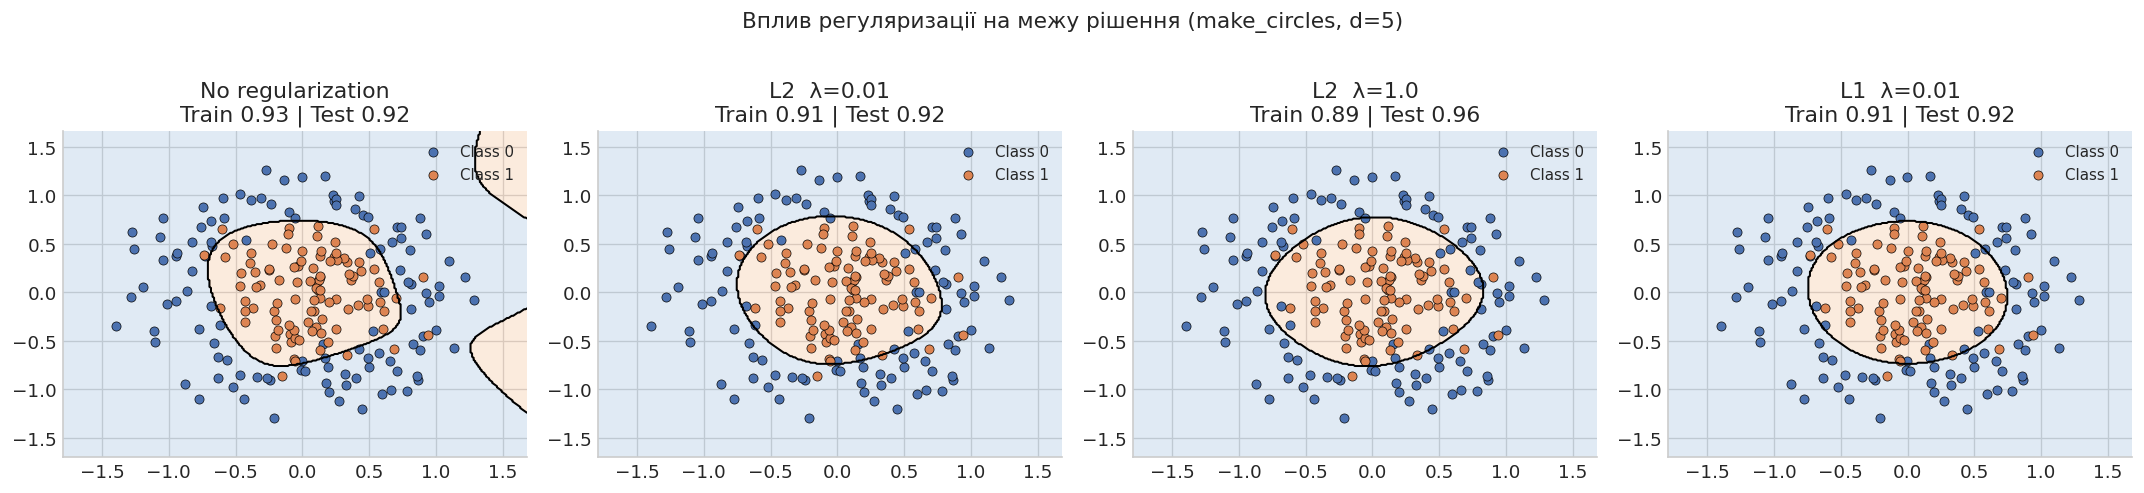

In [17]:
# --- Compare: no regularization vs L2 vs L1 ---
configs = [
    ("No regularization", dict(penalty=None,  lambda_=0)),
    ("L2  λ=0.01",        dict(penalty="l2",  lambda_=0.01)),
    ("L2  λ=1.0",         dict(penalty="l2",  lambda_=1.0)),
    ("L1  λ=0.01",        dict(penalty="l1",  lambda_=0.01)),
]

fig, axes = plt.subplots(1, 4, figsize=(18, 4))

for ax, (label, kwargs) in zip(axes, configs):
    model = LogisticRegression(
        learning_rate=0.5, n_iterations=2000,
        optimizer="bgd", **kwargs, random_state=RANDOM_STATE
    )
    model.fit(X_tr_scaled, y_tr)
    train_acc = accuracy_score(y_tr, model.predict(X_tr_scaled))
    test_acc  = accuracy_score(y_te, model.predict(X_te_scaled))

    plot_decision_boundary(model, X_tr, y_tr,
                           title=f"{label}\nTrain {train_acc:.2f} | Test {test_acc:.2f}",
                           ax=ax, poly=poly, scaler=scaler)

plt.suptitle("Вплив регуляризації на межу рішення (make_circles, d=5)", y=1.02, fontsize=13)
plt.tight_layout()
plt.show()

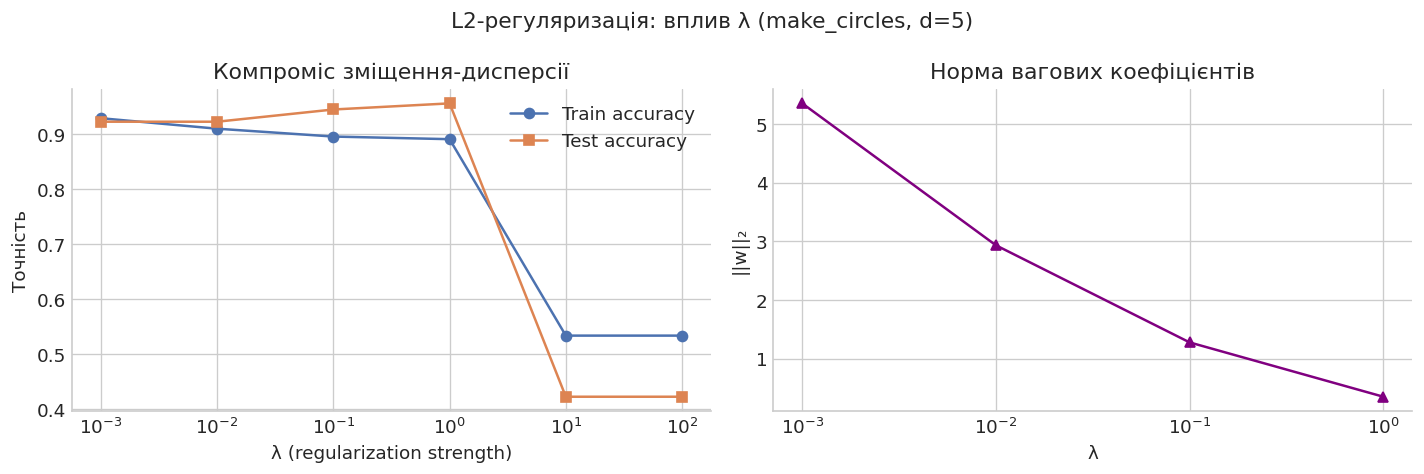

In [18]:
# --- Regularization strength sweep (λ values) ---
lambdas = [0.001, 0.01, 0.1, 1.0, 10.0, 100.0]
train_accs, test_accs, weight_norms = [], [], []

for lam in lambdas:
    m = LogisticRegression(learning_rate=0.5, n_iterations=2000,
                           optimizer="bgd", penalty="l2", lambda_=lam,
                           random_state=RANDOM_STATE)
    m.fit(X_tr_scaled, y_tr)
    train_accs.append(accuracy_score(y_tr, m.predict(X_tr_scaled)))
    test_accs.append(accuracy_score(y_te, m.predict(X_te_scaled)))
    weight_norms.append(np.linalg.norm(m.weights_))

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))

ax1.semilogx(lambdas, train_accs, "o-", color=COLORS[0], label="Train accuracy")
ax1.semilogx(lambdas, test_accs,  "s-", color=COLORS[1], label="Test accuracy")
ax1.set_xlabel("λ (regularization strength)")
ax1.set_ylabel("Точність")
ax1.set_title("Компроміс зміщення-дисперсії")
ax1.legend()

ax2.semilogx(lambdas, weight_norms, "^-", color="purple")
ax2.set_xlabel("λ")
ax2.set_ylabel("||w||₂")
ax2.set_title("Норма вагових коефіцієнтів")

plt.suptitle("L2-регуляризація: вплив λ (make_circles, d=5)", fontsize=13)
plt.tight_layout()
plt.show()

Best λ by test accuracy: 1.0
────────────────────────────────────────
  Best L2 model (λ=1.0) - Test set
────────────────────────────────────────
  Accuracy  : 0.9556
  Precision : 0.9615
  Recall    : 0.9615
  F1-score  : 0.9615
────────────────────────────────────────


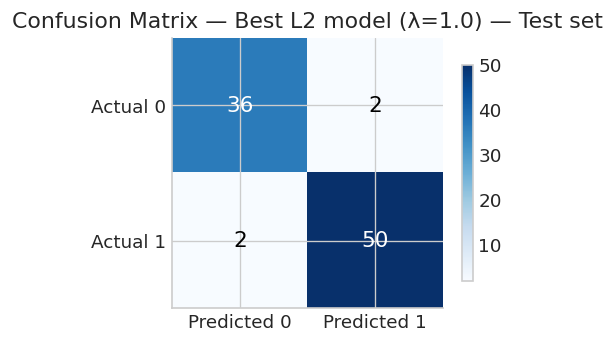

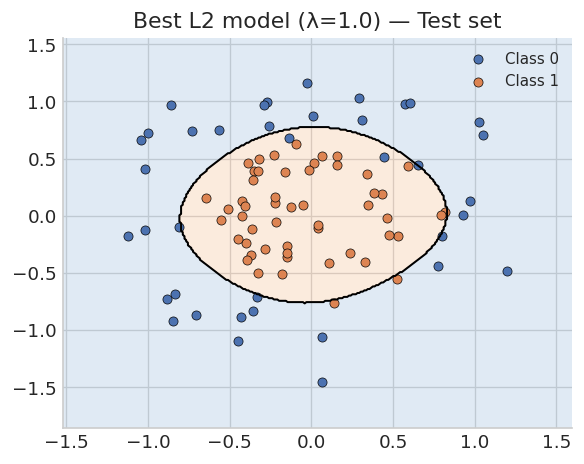

{'accuracy': 0.9555555555555556,
 'precision': 0.9615384615384616,
 'recall': 0.9615384615384616,
 'f1': 0.9615384615384616}

In [19]:
# --- Full evaluation of best L2 model ---
best_lam = lambdas[np.argmax(test_accs)]
print(f"Best λ by test accuracy: {best_lam}")

best_model = LogisticRegression(learning_rate=0.5, n_iterations=2000,
                                optimizer="bgd", penalty="l2", lambda_=best_lam,
                                random_state=RANDOM_STATE)
best_model.fit(X_tr_scaled, y_tr)
evaluate_and_plot(best_model, X_te, y_te,
                  title=f"Best L2 model (λ={best_lam}) - Test set",
                  poly=poly, scaler=scaler)

---
<a id='early-stopping'></a>
## 3. Рання зупинка

### 3.1 Теорія

**Рання зупинка** (early stopping) - це форма регуляризації, яка *не змінює* функцію втрат, але зупиняє навчання, коли втрата на **валідаційній** вибірці перестає зменшуватись.

#### Алгоритм

1. Виділити невелику валідаційну вибірку (10–20% тренувальних даних).
2. Після кожної ітерації обчислити $\mathcal{L}_{val}$.
3. Якщо $\mathcal{L}_{val}$ не покращилась більш ніж на $\tau$ (tolerance) протягом $p$ (patience) ітерацій - зупинити навчання і **відновити** ваги з найкращого чекпоінту.

```
best_val_loss = ∞
no_improve = 0

for each iteration:
    update weights
    val_loss = compute_loss(X_val, y_val)
    if val_loss < best_val_loss - τ:
        best_val_loss = val_loss
        save weights
        no_improve = 0
    else:
        no_improve += 1
    if no_improve ≥ patience:
        restore best weights
        break
```

In [20]:
# --- Dataset: make_moons (with noise to make overfitting easier to see) ---
X_moon, y_moon = make_moons(n_samples=400, noise=0.25, random_state=RANDOM_STATE)
X_tr_m, X_te_m, y_tr_m, y_te_m = train_test_split(
    X_moon, y_moon, test_size=0.25, random_state=RANDOM_STATE)

# Polynomial features + scaling
poly_m  = PolynomialFeatures(degree=6, include_bias=False)
scaler_m = StandardScaler()
X_tr_m_s = scaler_m.fit_transform(poly_m.fit_transform(X_tr_m))
X_te_m_s  = scaler_m.transform(poly_m.transform(X_te_m))

# Train WITHOUT early stopping (may overfit)
model_no_es = LogisticRegression(
    learning_rate=0.3, n_iterations=5000,
    optimizer="bgd", penalty=None,
    early_stopping=False, random_state=RANDOM_STATE
)
model_no_es.fit(X_tr_m_s, y_tr_m)

# Train WITH early stopping
model_es = LogisticRegression(
    learning_rate=0.3, n_iterations=5000,
    optimizer="bgd", penalty=None,
    early_stopping=True, validation_fraction=0.15,
    n_iter_no_change=30, tol=1e-4,
    random_state=RANDOM_STATE
)
model_es.fit(X_tr_m_s, y_tr_m)

print(f"Without early stopping - stopped at iteration: {model_no_es.n_iter_}")
print(f"With    early stopping - stopped at iteration: {model_es.n_iter_}")

Without early stopping - stopped at iteration: 5000
With    early stopping - stopped at iteration: 3846


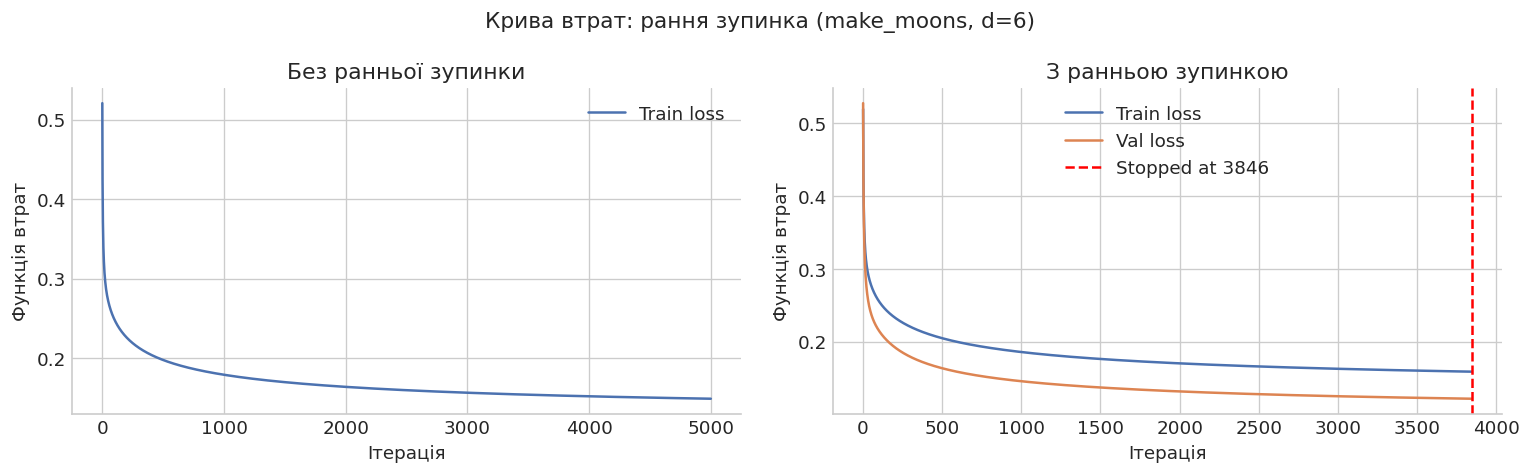

In [21]:
# --- Plot loss curves ---
diag_no_es = model_no_es.get_diagnostics()
diag_es    = model_es.get_diagnostics()

fig, axes = plt.subplots(1, 2, figsize=(13, 4))

# Without early stopping
axes[0].plot(diag_no_es["train_losses"], label="Train loss", color=COLORS[0])
axes[0].set_title("Без ранньої зупинки")
axes[0].set_xlabel("Ітерація"); axes[0].set_ylabel("Функція втрат")
axes[0].legend()

# With early stopping - both train and val
axes[1].plot(diag_es["train_losses"], label="Train loss", color=COLORS[0])
axes[1].plot(diag_es["val_losses"],   label="Val loss",   color=COLORS[1])
axes[1].axvline(model_es.n_iter_, color="red", linestyle="--",
                label=f"Stopped at {model_es.n_iter_}")
axes[1].set_title("З ранньою зупинкою")
axes[1].set_xlabel("Ітерація"); axes[1].set_ylabel("Функція втрат")
axes[1].legend()

plt.suptitle("Крива втрат: рання зупинка (make_moons, d=6)", fontsize=13)
plt.tight_layout()
plt.show()

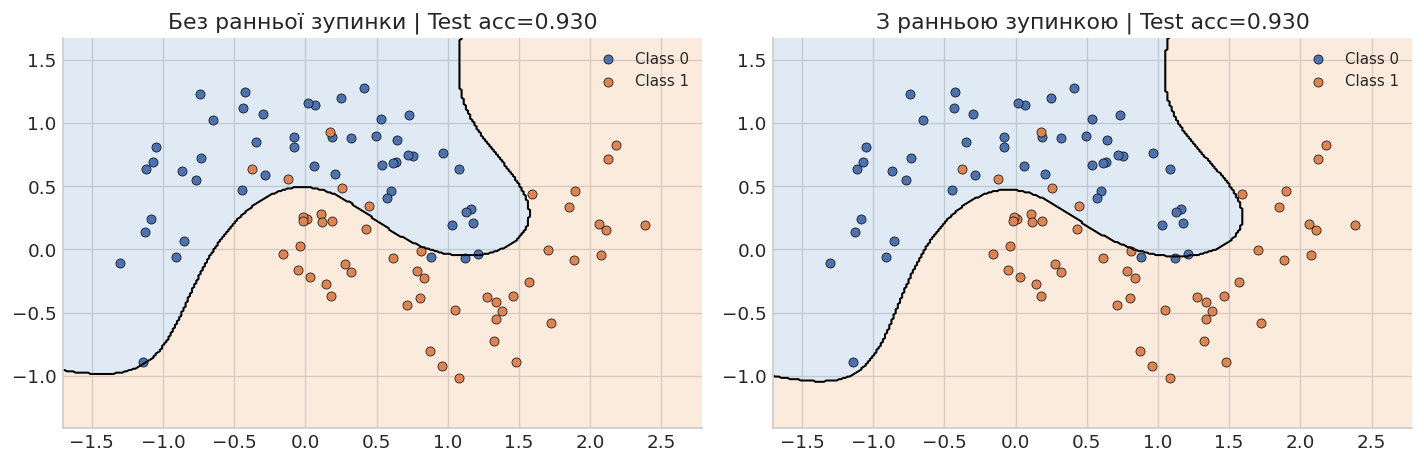

In [22]:
# --- Compare decision boundaries and test metrics ---
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

for ax, model, label in [
    (axes[0], model_no_es, "Без ранньої зупинки"),
    (axes[1], model_es,    "З ранньою зупинкою"),
]:
    test_acc = accuracy_score(y_te_m, model.predict(X_te_m_s))
    plot_decision_boundary(model, X_te_m, y_te_m,
                           title=f"{label} | Test acc={test_acc:.3f}",
                           ax=ax, poly=poly_m, scaler=scaler_m)

plt.tight_layout()
plt.show()

---
<a id='optimizers'></a>
## 4. Методи градієнтного спуску: BGD, SGD та MBGD

### 4.1 Теорія

Всі три методи мінімізують одну і ту ж функцію втрат, але відрізняються **кількістю прикладів**,
що використовуються для обчислення одного оновлення ваг.

| Метод | Кількість прикладів | Оновлення за епоху |
|---|---|---|
| **BGD** (Batch GD) | Всі $m$ | 1 |
| **SGD** (Stochastic GD) | 1 | $m$ |
| **MBGD** (Mini-Batch GD) | $b \ll m$ | $m/b$ |

#### Формула оновлення (загальна)

$$\mathbf{w} \leftarrow \mathbf{w} - \eta \cdot \nabla_{\mathbf{w}}\mathcal{L}_{\text{batch}}$$

де $\eta$ - швидкість навчання, а batch - вся вибірка (BGD), один приклад (SGD) або міні-пакет (MBGD).

**Порівняння:**
* **BGD** - стабільне, але повільне на великих даних.
* **SGD** - швидке оновлення, шумна траєкторія, може «вилетіти» з мінімуму.
* **MBGD** - золота середина: достатньо стабільний і ефективний.

In [23]:
# --- Dataset: make_blobs (easy baseline for comparing convergence) ---
X_blob, y_blob = make_blobs(n_samples=1024, centers=2, cluster_std=1.5,
                             random_state=RANDOM_STATE)
X_tr_b, X_te_b, y_tr_b, y_te_b = train_test_split(
    X_blob, y_blob, test_size=0.25, random_state=RANDOM_STATE)

scaler_b = StandardScaler()
X_tr_b_s = scaler_b.fit_transform(X_tr_b)
X_te_b_s  = scaler_b.transform(X_te_b)

# --- Train three optimizers ---
optimizer_configs = {
    "BGD":  dict(optimizer="bgd",  learning_rate=0.5,  batch_size=None),
    "SGD":  dict(optimizer="sgd",  learning_rate=0.05, batch_size=None),
    "MBGD": dict(optimizer="mbgd", learning_rate=0.2,  batch_size=32),
}

models = {}
for name, cfg in optimizer_configs.items():
    m = LogisticRegression(n_iterations=200, penalty="l2", lambda_=0.01,
                           random_state=RANDOM_STATE, **cfg)
    m.fit(X_tr_b_s, y_tr_b)
    models[name] = m
    print(f"{name:5s} - final train loss: {m.train_losses_[-1]:.4f} | "
          f"test acc: {accuracy_score(y_te_b, m.predict(X_te_b_s)):.4f}")

BGD   - final train loss: 0.0824 | test acc: 0.9961
SGD   - final train loss: 0.1142 | test acc: 0.9961
MBGD  - final train loss: 0.0824 | test acc: 0.9961


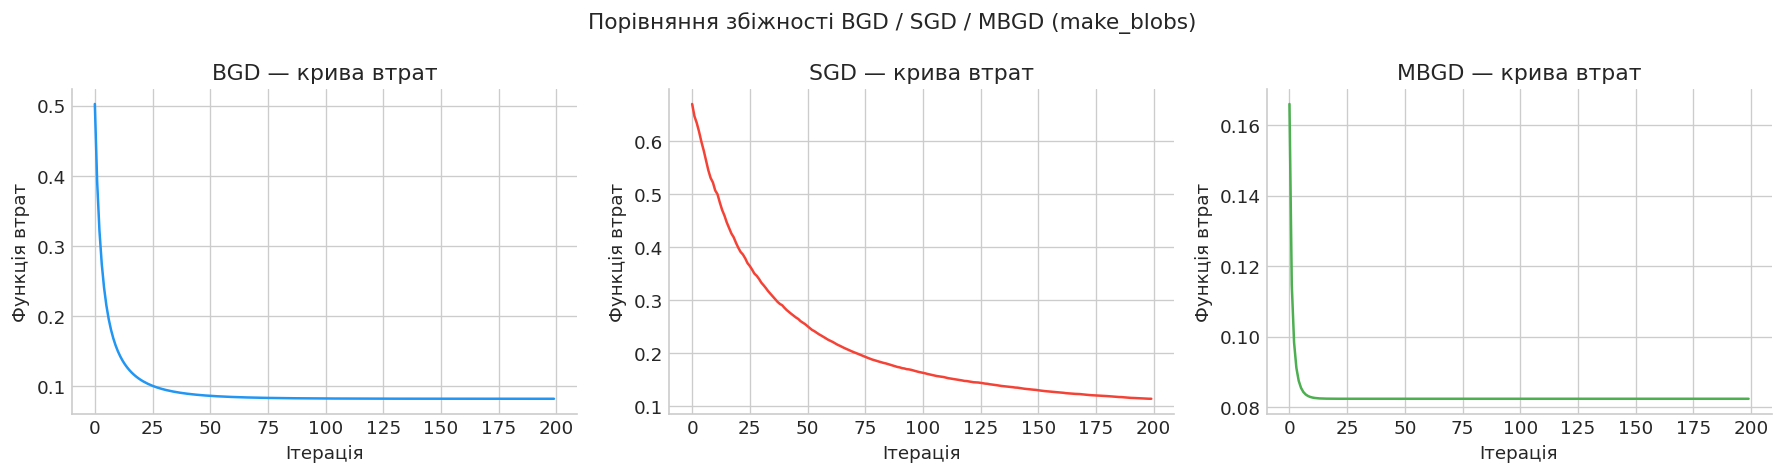

In [24]:
# --- Loss curves for all three optimizers ---
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
opt_colors = {"BGD": "#2196F3", "SGD": "#F44336", "MBGD": "#4CAF50"}

for ax, (name, model) in zip(axes, models.items()):
    diag = model.get_diagnostics()
    ax.plot(diag["train_losses"], color=opt_colors[name], linewidth=1.5)
    ax.set_title(f"{name} - крива втрат")
    ax.set_xlabel("Ітерація")
    ax.set_ylabel("Функція втрат")

plt.suptitle("Порівняння збіжності BGD / SGD / MBGD (make_blobs)", fontsize=13)
plt.tight_layout()
plt.show()

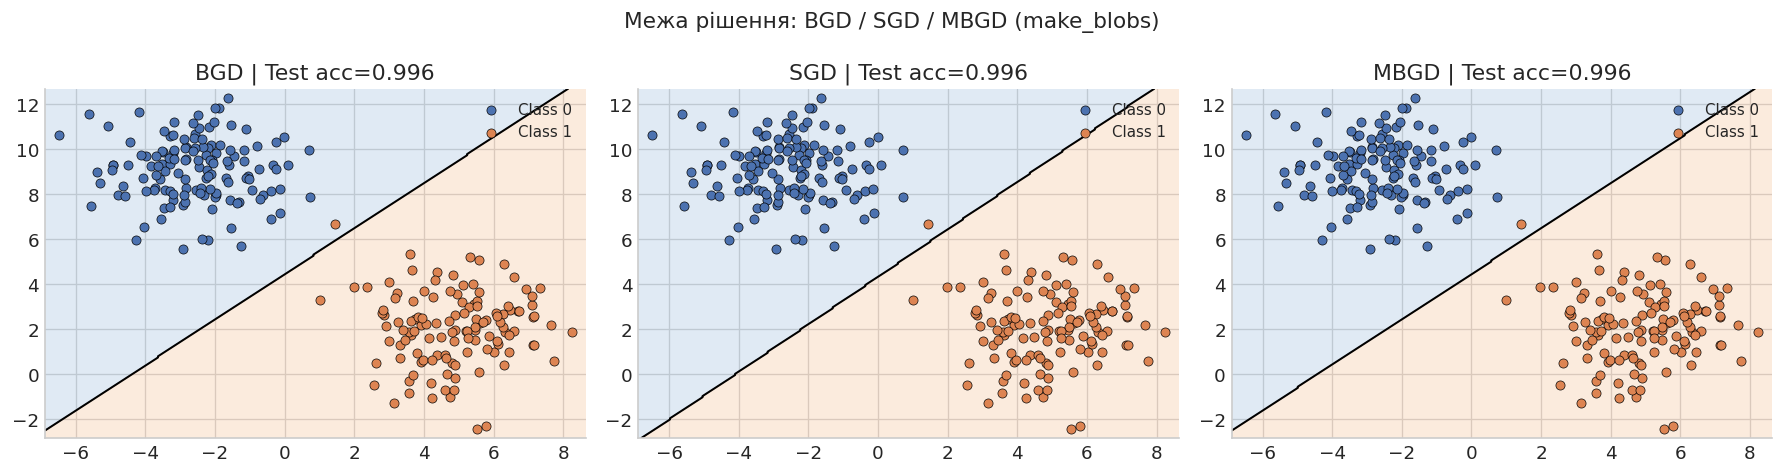

In [25]:
# --- Decision boundaries for all three ---
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

for ax, (name, model) in zip(axes, models.items()):
    acc = accuracy_score(y_te_b, model.predict(X_te_b_s))
    plot_decision_boundary(model, X_te_b, y_te_b,
                           title=f"{name} | Test acc={acc:.3f}",
                           ax=ax, scaler=scaler_b)

plt.suptitle("Межа рішення: BGD / SGD / MBGD (make_blobs)", fontsize=13)
plt.tight_layout()
plt.show()

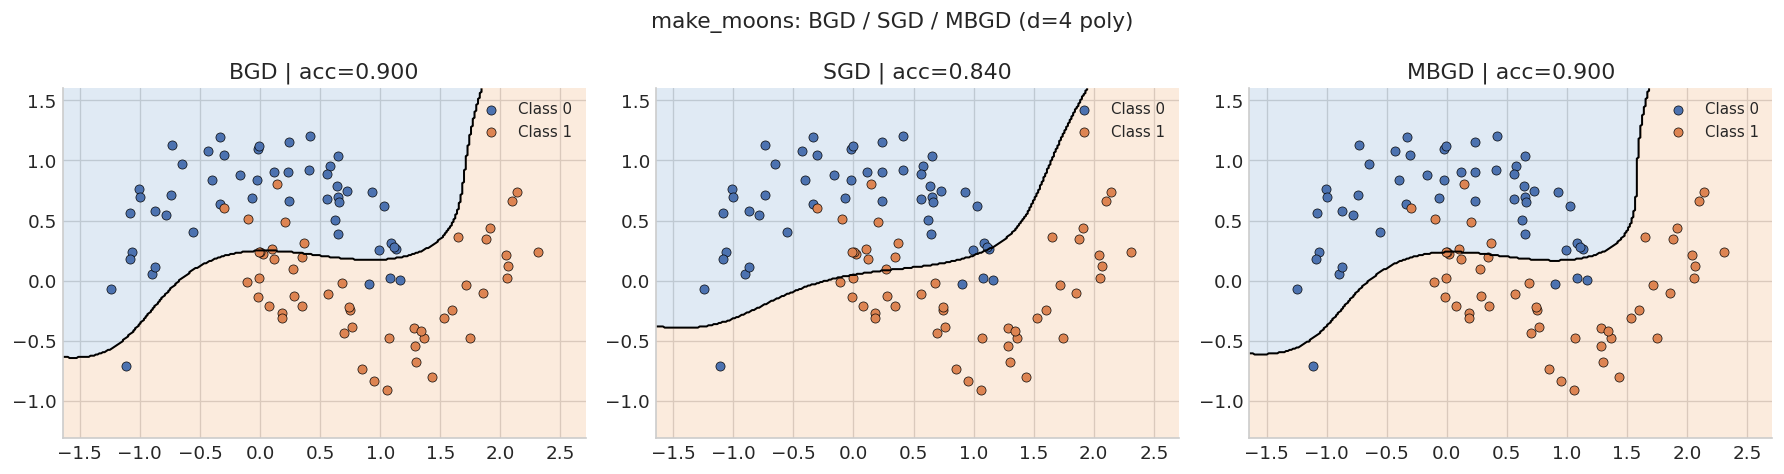

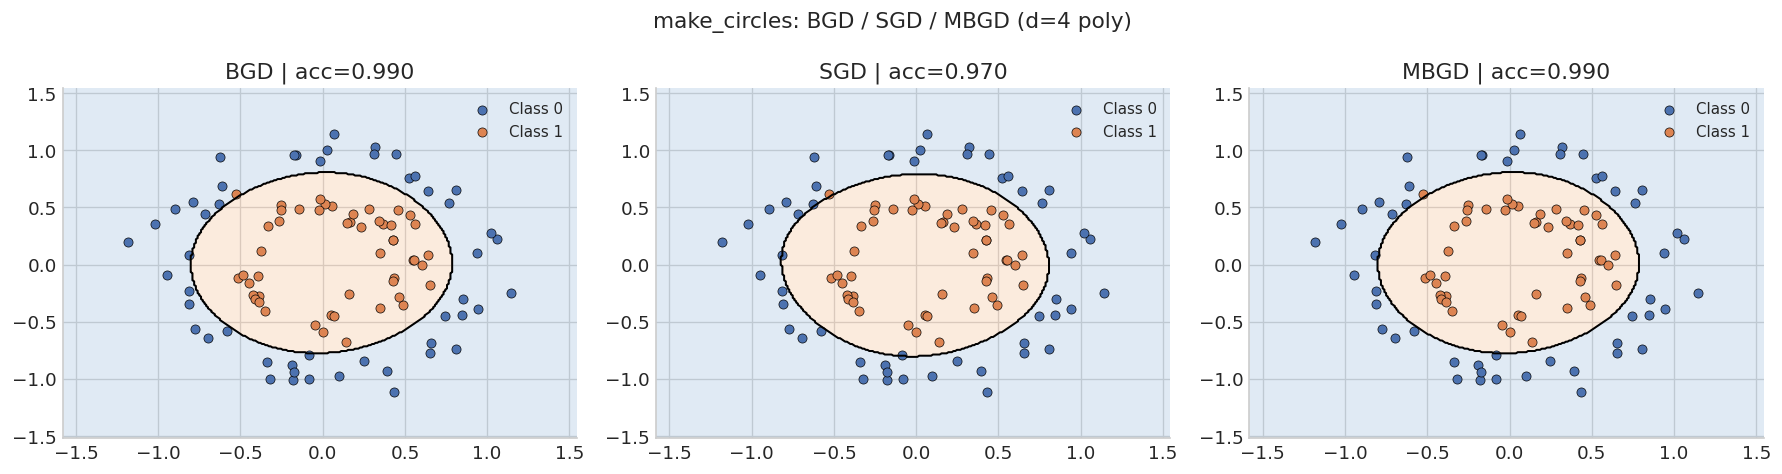

In [26]:
# --- Demo on make_moons and make_circles as well ---
datasets = {
    "make_moons":   make_moons(n_samples=400,  noise=0.2, random_state=RANDOM_STATE),
    "make_circles": make_circles(n_samples=400, noise=0.1, factor=0.5, random_state=RANDOM_STATE),
}

for ds_name, (X_ds, y_ds) in datasets.items():
    X_tr_ds, X_te_ds, y_tr_ds, y_te_ds = train_test_split(
        X_ds, y_ds, test_size=0.25, random_state=RANDOM_STATE)

    # Use polynomial features so boundary is non-linear
    poly_ds   = PolynomialFeatures(degree=4, include_bias=False)
    scaler_ds = StandardScaler()
    X_tr_ds_s = scaler_ds.fit_transform(poly_ds.fit_transform(X_tr_ds))
    X_te_ds_s  = scaler_ds.transform(poly_ds.transform(X_te_ds))

    fig, axes = plt.subplots(1, 3, figsize=(15, 4))
    for ax, (name, cfg) in zip(axes, optimizer_configs.items()):
        m = LogisticRegression(n_iterations=500, penalty="l2", lambda_=0.01,
                               random_state=RANDOM_STATE, **cfg)
        m.fit(X_tr_ds_s, y_tr_ds)
        acc = accuracy_score(y_te_ds, m.predict(X_te_ds_s))
        plot_decision_boundary(m, X_te_ds, y_te_ds,
                               title=f"{name} | acc={acc:.3f}",
                               ax=ax, poly=poly_ds, scaler=scaler_ds)
    plt.suptitle(f"{ds_name}: BGD / SGD / MBGD (d=4 poly)", fontsize=13)
    plt.tight_layout()
    plt.show()

---
<a id='diagnostics'></a>
## 5. Діагностика оптимізації

### 5.1 Теорія

Щоб зрозуміти, чи **збігається** наш оптимізатор коректно, аналізують:

| Метрика | Що показує |
|---|---|
| **Крива тренувальної втрати** | Чи зменшується втрата з кожною ітерацією? |
| **Крива валідаційної втрати** | Чи немає перенавчання (розходження train/val)? |
| **Норма градієнта** $\|\nabla\mathbf{w}\|_2$ | Чи наближаємось до мінімуму (норма → 0)? |

#### Типові «патерни» та їх значення

* Тренувальна втрата **не зменшується** → занадто мала $\eta$ або помилка в коді.
* Тренувальна втрата **осцилює** → занадто велика $\eta$.
* Val-втрата зростає, train падає → **перенавчання** - збільшіть $\lambda$ або використайте ранню зупинку.
* Норма градієнта не прямує до 0 → модель ще не збіглась.

In [27]:
# --- Full diagnostic dashboard for one model ---
X_d, y_d = make_moons(n_samples=500, noise=0.2, random_state=RANDOM_STATE)
X_tr_d, X_te_d, y_tr_d, y_te_d = train_test_split(
    X_d, y_d, test_size=0.25, random_state=RANDOM_STATE)

poly_d   = PolynomialFeatures(degree=5, include_bias=False)
scaler_d = StandardScaler()
X_tr_d_s = scaler_d.fit_transform(poly_d.fit_transform(X_tr_d))
X_te_d_s  = scaler_d.transform(poly_d.transform(X_te_d))

model_diag = LogisticRegression(
    learning_rate=0.3, n_iterations=1000,
    optimizer="bgd", penalty="l2", lambda_=0.01,
    early_stopping=True, validation_fraction=0.15,
    n_iter_no_change=40, tol=1e-5,
    random_state=RANDOM_STATE
)
model_diag.fit(X_tr_d_s, y_tr_d)
diag = model_diag.get_diagnostics()
print(f"Converged at iteration: {diag['n_iter']}")

Converged at iteration: 847


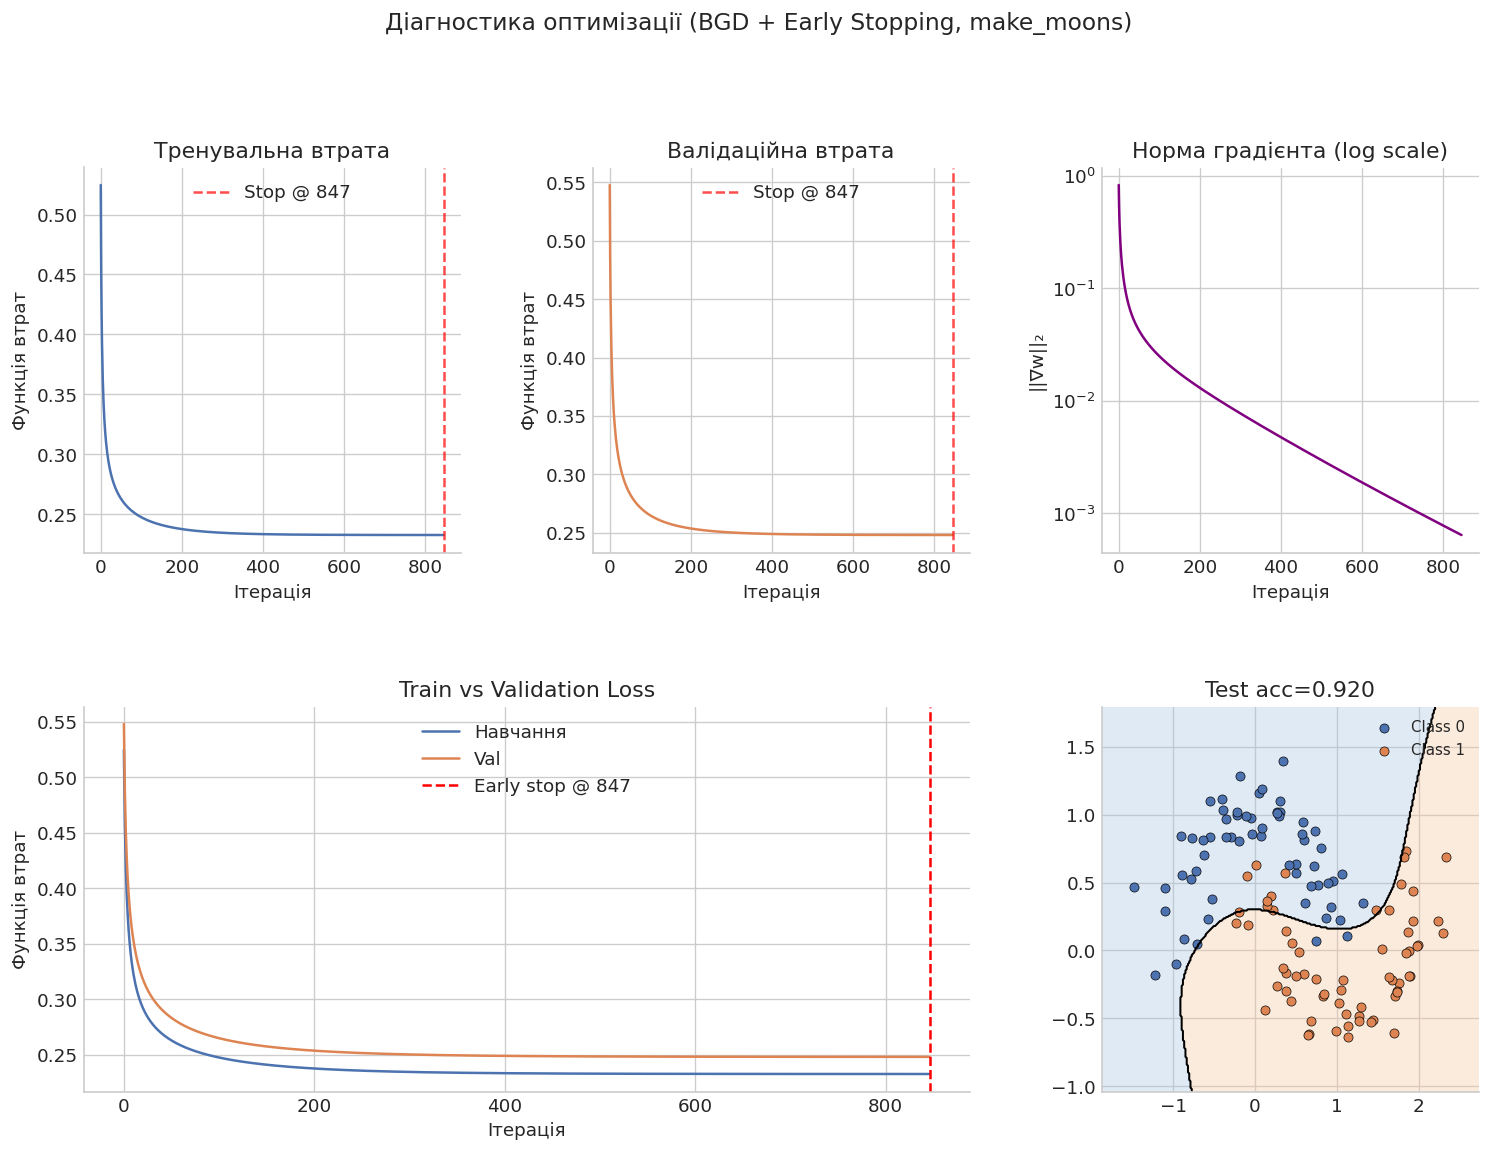

In [28]:
# --- Diagnostic dashboard ---
fig = plt.figure(figsize=(15, 10))
gs  = gridspec.GridSpec(2, 3, figure=fig, hspace=0.4, wspace=0.35)

# 1. Train loss
ax1 = fig.add_subplot(gs[0, 0])
ax1.plot(diag["train_losses"], color=COLORS[0])
ax1.axvline(diag["n_iter"], color="red", linestyle="--", alpha=0.7,
            label=f"Stop @ {diag['n_iter']}")
ax1.set_title("Тренувальна втрата")
ax1.set_xlabel("Ітерація"); ax1.set_ylabel("Функція втрат")
ax1.legend()

# 2. Val loss
ax2 = fig.add_subplot(gs[0, 1])
ax2.plot(diag["val_losses"], color=COLORS[1])
ax2.axvline(diag["n_iter"], color="red", linestyle="--", alpha=0.7,
            label=f"Stop @ {diag['n_iter']}")
ax2.set_title("Валідаційна втрата")
ax2.set_xlabel("Ітерація"); ax2.set_ylabel("Функція втрат")
ax2.legend()

# 3. Gradient norm
ax3 = fig.add_subplot(gs[0, 2])
ax3.semilogy(diag["grad_norms"], color="purple")
ax3.set_title("Норма градієнта (log scale)")
ax3.set_xlabel("Ітерація"); ax3.set_ylabel("||∇w||₂")

# 4. Train + Val on the same plot
ax4 = fig.add_subplot(gs[1, 0:2])
ax4.plot(diag["train_losses"], label="Навчання", color=COLORS[0])
ax4.plot(diag["val_losses"],   label="Val",   color=COLORS[1])
ax4.axvline(diag["n_iter"], color="red", linestyle="--",
            label=f"Early stop @ {diag['n_iter']}")
ax4.set_title("Train vs Validation Loss")
ax4.set_xlabel("Ітерація"); ax4.set_ylabel("Функція втрат")
ax4.legend()

# 5. Decision boundary on test set
ax5 = fig.add_subplot(gs[1, 2])
acc_test = accuracy_score(y_te_d, model_diag.predict(X_te_d_s))
plot_decision_boundary(model_diag, X_te_d, y_te_d,
                       title=f"Test acc={acc_test:.3f}",
                       ax=ax5, poly=poly_d, scaler=scaler_d)

plt.suptitle("Діагностика оптимізації (BGD + Early Stopping, make_moons)",
             fontsize=14, y=1.01)
plt.show()

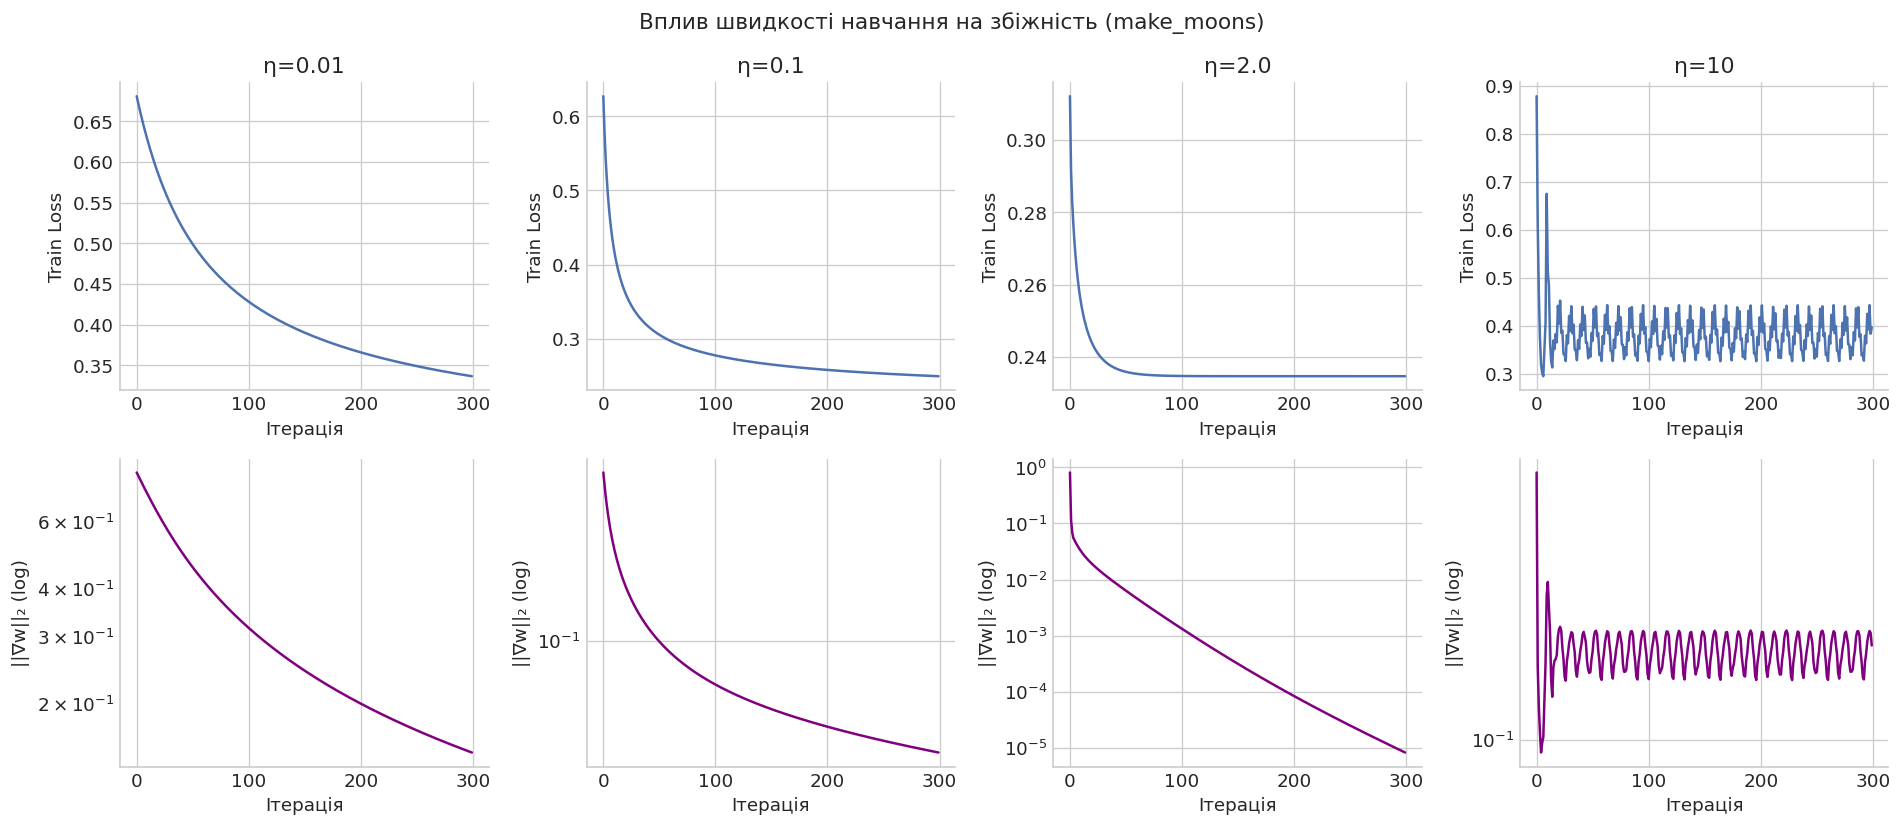

In [29]:
# --- Compare diagnostics: different learning rates ---
learning_rates = [0.01, 0.1, 2.0, 10]

fig, axes = plt.subplots(2, len(learning_rates), figsize=(16, 7))
for col, lr in enumerate(learning_rates):
    m = LogisticRegression(
        learning_rate=lr, n_iterations=300,
        optimizer="bgd", penalty="l2", lambda_=0.01,
        random_state=RANDOM_STATE
    )
    m.fit(X_tr_d_s, y_tr_d)
    d = m.get_diagnostics()

    # Loss
    axes[0, col].plot(d["train_losses"], color=COLORS[0])
    axes[0, col].set_title(f"η={lr}")
    axes[0, col].set_ylabel("Train Loss")
    axes[0, col].set_xlabel("Ітерація")

    # Gradient norm
    axes[1, col].semilogy(d["grad_norms"], color="purple")
    axes[1, col].set_ylabel("||∇w||₂ (log)")
    axes[1, col].set_xlabel("Ітерація")

plt.suptitle("Вплив швидкості навчання на збіжність (make_moons)", fontsize=13)
plt.tight_layout()
plt.show()

ПІДСУМКОВА ОЦІНКА НАЙКРАЩОЇ МОДЕЛІ
────────────────────────────────────────
  BGD + L2 + Early Stopping (make_moons)
────────────────────────────────────────
  Accuracy  : 0.9200
  Precision : 0.9655
  Recall    : 0.8750
  F1-score  : 0.9180
────────────────────────────────────────


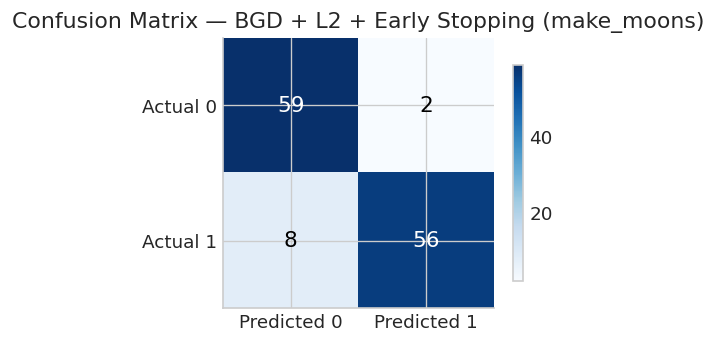

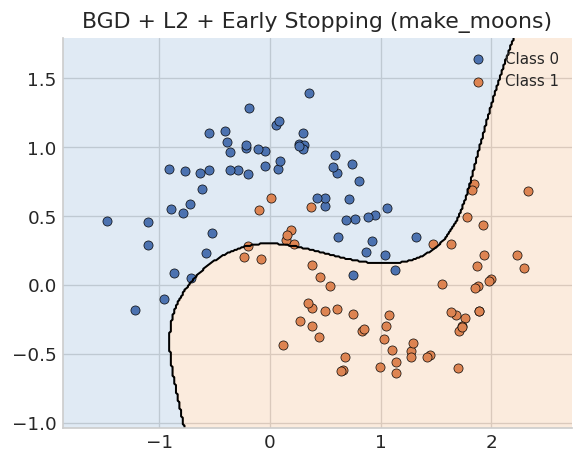

{'accuracy': 0.92,
 'precision': 0.9655172413793104,
 'recall': 0.875,
 'f1': 0.9180327868852459}

In [30]:
# --- Final full evaluation ---
print("=" * 50)
print("ПІДСУМКОВА ОЦІНКА НАЙКРАЩОЇ МОДЕЛІ")
print("=" * 50)
evaluate_and_plot(model_diag, X_te_d, y_te_d,
                  title="BGD + L2 + Early Stopping (make_moons)",
                  poly=poly_d, scaler=scaler_d)

---
## Підсумок

| Тема | Ключовий висновок |
|---|---|
| **Регуляризація** | L1/L2 обмежують норму ваг і зменшують перенавчання; L1 дає розріджені рішення |
| **Рання зупинка** | Проста та ефективна форма регуляризації без зміни функції втрат |
| **BGD** | Стабільна збіжність, але обчислювально дорого на великих даних |
| **SGD** | Швидке, шумне; добре для великих датасетів з відповідним LR |
| **MBGD** | Найкращий практичний баланс між стабільністю та швидкістю |
| **Діагностика** | Аналіз кривих втрат і норм градієнтів - обовʼязковий крок після навчання |


## Підсумок

У цій лабораторній роботі ви:

- Реалізували ключові алгоритми з нуля за допомогою NumPy
- Візуалізували результати та інтерпретували поведінку моделей
- Порівняли різні підходи та дослідили їхні переваги і обмеження